# 구모델 시뮬레이션 — 환경변수·물리적리스크 미반영 baseline

**프로젝트**: 대한민국화재 P&C 화재보험 ESG underwriting 분석

**본 노트북의 목적**: ESG 도입 이전의 "구모델"이 30년 시뮬레이션에서 **지속적 손해 누적 구조**를 보이는 이유를 정량적으로 분석한다.

## 구모델의 가정

구모델은 환경 관련 변수 (탄소집약도 ρ, 전환노력 M, 물리적 리스크 PRF) 를 일체 고려하지 않는 baseline 시나리오:
- 모든 firm에 산업별 평균 요율 동일 적용 (DF = 1)
- 손해율 보정 없음 (PRF 미적용)
- 자본효율·시장가치 채널 미작동 (V2, AA = 0)
- V1 (영업손익) 채널만 작동

## NPV 적용

구모델의 30년 영업손익 시계열에 **V1 할인율 ($r_{V1}$ = 2.7%, IFRS 17 30Y 무위험 국고채 기준) 을 적용한 NPV** 도 함께 산출하여, nominal 누적 손실과 시간가치 반영 누적 손실을 비교한다.

## 1. 라이브러리 import 및 환경 설정

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# 한글 폰트 (Mac 기준)
plt.rcParams['font.family'] = 'AppleGothic'
# Windows: 'Malgun Gothic' / Linux: 'NanumGothic' 으로 변경
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 부호 깨짐 방지
plt.rcParams['font.size'] = 11

print('환경 설정 완료')

환경 설정 완료


## 2. 엑셀 파일에서 파라미터 로딩

최종 엑셀 (`학술제시트_520_아마최종.xlsx`) 의 '5. 통합' 시트에서 다음 값을 직접 추출:

| 셀 위치 | 의미 | 사용 변수 |
|---|---|---|
| `B3` ~ `D3` | t=0 EP_구, 손해_구, 사업비_구 | `EP_0`, `Loss_0`, `Expense_0` |
| `B41` | 보험료 인상률 | `g_premium` |
| `B42` | 손해 가속률 | `g_actual` |
| `B53` | V1 할인율 (NPV용) | `r_V1` |

In [12]:
# ─── 엑셀 파일 경로 ───
EXCEL_PATH = '/Users/dapanman/Downloads/학술제시트_520_아마최종.xlsx'

# 워크북 로드 (data_only=True : 수식 결과값을 읽기)
wb = load_workbook(EXCEL_PATH, data_only=True)
ws = wb['5. 통합']

# ─── t=0 초기값 (5. 통합 시트 row 3) ───
EP_0      = ws.cell(row=3, column=2).value   # B3: EP_구
Loss_0    = ws.cell(row=3, column=3).value   # C3: 손해_구
Expense_0 = ws.cell(row=3, column=4).value   # D3: 사업비_구

# ─── 핵심 증가율 (모델 가정 영역) ───
g_premium = ws.cell(row=41, column=2).value  # B41: 보험료 인상률
g_actual  = ws.cell(row=42, column=2).value  # B42: 손해 가속률

# ─── NPV 할인율 (IFRS 17 30Y 무위험 국고채) ───
r_V1      = ws.cell(row=53, column=2).value  # B53: r_V1

# ─── 파생 비율 ───
LR_0 = Loss_0 / EP_0          # t=0 손해율
ER_0 = Expense_0 / EP_0       # t=0 사업비율 (시계열 상수)
CR_0 = LR_0 + ER_0            # t=0 합계비율

# 출력 확인
print('=' * 65)
print('엑셀에서 로드된 구모델 파라미터')
print('=' * 65)
print(f'EP_0 (보험료, t=0)         = {EP_0:>10,.1f} 억원')
print(f'Loss_0 (손해, t=0)         = {Loss_0:>10,.1f} 억원   (LR = {LR_0:.2%})')
print(f'Expense_0 (사업비, t=0)    = {Expense_0:>10,.1f} 억원   (ER = {ER_0:.2%})')
print(f'합계비율 (CR, t=0)         = {CR_0:.2%}')
print(f'영업이익 (t=0)             = {EP_0 - Loss_0 - Expense_0:>10,.1f} 억원')
print()
print(f'g_premium (보험료 인상률)  = {g_premium:.2%} / 년')
print(f'g_actual (손해 가속률)     = {g_actual:.2%} / 년')
print(f'증가율 격차 (Δg)           = {g_actual - g_premium:.2%} / 년')
print()
print(f'r_V1 (V1 할인율)           = {r_V1:.2%} / 년')

엑셀에서 로드된 구모델 파라미터
EP_0 (보험료, t=0)         =    7,524.0 억원
Loss_0 (손해, t=0)         =    4,785.0 억원   (LR = 63.60%)
Expense_0 (사업비, t=0)    =    2,317.4 억원   (ER = 30.80%)
합계비율 (CR, t=0)         = 94.40%
영업이익 (t=0)             =      421.6 억원

g_premium (보험료 인상률)  = 4.00% / 년
g_actual (손해 가속률)     = 5.00% / 년
증가율 격차 (Δg)           = 1.00% / 년

r_V1 (V1 할인율)           = 2.70% / 년


## 3. 구모델 시뮬레이션

### 핵심 수식

$$EP_{old}(t) = EP_0 \cdot (1 + g_{premium})^t$$

$$Loss_{old}(t) = Loss_0 \cdot (1 + g_{actual})^t$$

$$Expense_{old}(t) = EP_{old}(t) \cdot ER_0$$

$$\text{영업손익}_{old}(t) = EP_{old}(t) - Loss_{old}(t) - Expense_{old}(t)$$

### NPV 계산 (V1 채널)

$$NPV_{old}(t) = \text{영업손익}_{old}(t) \cdot \frac{1}{(1 + r_{V1})^t}$$

$$\text{누적 NPV}_{old}(T) = \sum_{t=0}^{T} NPV_{old}(t)$$

In [13]:
# ─── 시간 horizon ───
T_MAX = 30
years = np.arange(0, T_MAX + 1)

# ─── 시계열 계산 ───
EP_old      = EP_0    * (1 + g_premium) ** years
Loss_old    = Loss_0  * (1 + g_actual)  ** years
Expense_old = EP_old  * ER_0                                  # EP 의 30.8% 가 사업비
Profit_old  = EP_old - Loss_old - Expense_old                  # 영업손익 (raw, nominal)

# ─── 비율 시계열 ───
LR_t = Loss_old    / EP_old                                    # 손해율 (시간 가변)
ER_t = Expense_old / EP_old                                    # 사업비율 (= ER_0 상수)
CR_t = LR_t + ER_t                                              # 합계비율

# ─── NPV 계산 (V1 할인율 r_V1 적용) ───
discount_factor = 1.0 / (1 + r_V1) ** years                    # 할인계수
NPV_annual      = Profit_old * discount_factor                 # 매년 NPV
Cum_NPV         = np.cumsum(NPV_annual)                        # 누적 NPV

# ─── 누적 (nominal, 비교용) ───
Cum_Profit_nominal = np.cumsum(Profit_old)

# ─── DataFrame 정리 ───
df = pd.DataFrame({
    't': years,
    'EP_구': EP_old,
    '손해_구': Loss_old,
    '사업비_구': Expense_old,
    '영업손익_구': Profit_old,
    'NPV_매년': NPV_annual,
    '누적_NPV': Cum_NPV,
    '누적_손익_nominal': Cum_Profit_nominal,
    '손해율(%)': LR_t * 100,
    '합계비율(%)': CR_t * 100,
})

# 주요 시점만 표시
key_years = [0, 5, 9, 10, 15, 16, 20, 25, 30]
df.iloc[key_years].round(1)

,t,EP_구,손해_구,사업비_구,영업손익_구,NPV_매년,누적_NPV,누적_손익_nominal,손해율(%),합계비율(%)
0,0,7524.0,4785.0,2317.4,421.6,421.6,421.6,421.6,63.6,94.4
5,5,9154.0,6107.0,2819.4,227.6,199.2,1878.7,1988.0,66.7,97.5
9,9,10708.9,7423.1,3298.4,-12.5,-9.8,2162.1,2325.6,69.3,100.1
10,10,11137.3,7794.2,3430.3,-87.2,-66.8,2095.3,2238.3,70.0,100.8
15,15,13550.2,9947.7,4173.5,-570.9,-382.8,834.4,430.1,73.4,104.2
16,16,14092.2,10445.0,4340.4,-693.2,-452.6,381.8,-263.1,74.1,104.9
20,20,16485.9,12696.0,5077.7,-1287.8,-755.8,-2174.4,-4466.3,77.0,107.8
25,25,20057.6,16203.7,6177.7,-2323.8,-1193.8,-7239.8,-13865.0,80.8,111.6
30,30,24403.2,20680.5,7516.2,-3793.5,-1705.8,-14713.3,-29692.4,84.7,115.5


### 핵심 변곡점 식별

- **단년 영업적자**: 첫 음수 도달 시점 (Profit < 0)
- **합계비율 100% 돌파**: CR(t) ≥ 100%
- **누적 nominal 음수**: 할인 없는 누적이 음수로 전환
- **누적 NPV 음수**: 할인 적용 누적이 음수로 전환

In [14]:
# 변곡점 검출 함수
def first_negative(arr):
    return next((t for t, v in enumerate(arr) if v < 0), None)

def first_above(arr, threshold):
    return next((t for t, v in enumerate(arr) if v >= threshold), None)

deficit_year  = first_negative(Profit_old)                          # 단년 적자
cr_100_year   = first_above(CR_t, 1.0)                              # CR 100% 돌파
cum_neg_year  = first_negative(Cum_Profit_nominal)                  # nominal 누적 음수
npv_neg_year  = first_negative(Cum_NPV)                             # NPV 누적 음수

print('=' * 65)
print('구모델 핵심 변곡점')
print('=' * 65)
print(f'단년 영업적자 첫 도달  : t = {deficit_year}년  (영_구 = {Profit_old[deficit_year]:+,.1f} 억)')
print(f'합계비율 100% 돌파      : t = {cr_100_year}년  (CR = {CR_t[cr_100_year]:.2%})')
print(f'누적 nominal 음수 전환  : t = {cum_neg_year}년')
print(f'누적 NPV 음수 전환      : t = {npv_neg_year}년')
print()
print(f'30년 시점 단년 손익     : {Profit_old[30]:>+12,.1f} 억')
print(f'30년 누적 nominal       : {Cum_Profit_nominal[30]:>+12,.1f} 억')
print(f'30년 누적 NPV (r={r_V1:.1%}) : {Cum_NPV[30]:>+12,.1f} 억')

구모델 핵심 변곡점
단년 영업적자 첫 도달  : t = 9년  (영_구 = -12.5 억)
합계비율 100% 돌파      : t = 9년  (CR = 100.12%)
누적 nominal 음수 전환  : t = 16년
누적 NPV 음수 전환      : t = 17년

30년 시점 단년 손익     :     -3,793.5 억
30년 누적 nominal       :    -29,692.4 억
30년 누적 NPV (r=2.7%) :    -14,713.3 억


## 4. 시각화 — Chart 1 : EP_구 vs 손해_구 (절대값 trajectory)

보험료와 손해의 절대 금액 변화를 비교. 손해 (5%/년) 가 보험료 (4%/년) 보다 빠르게 증가하여 두 곡선이 교차한 후 손해가 보험료를 추월한다.

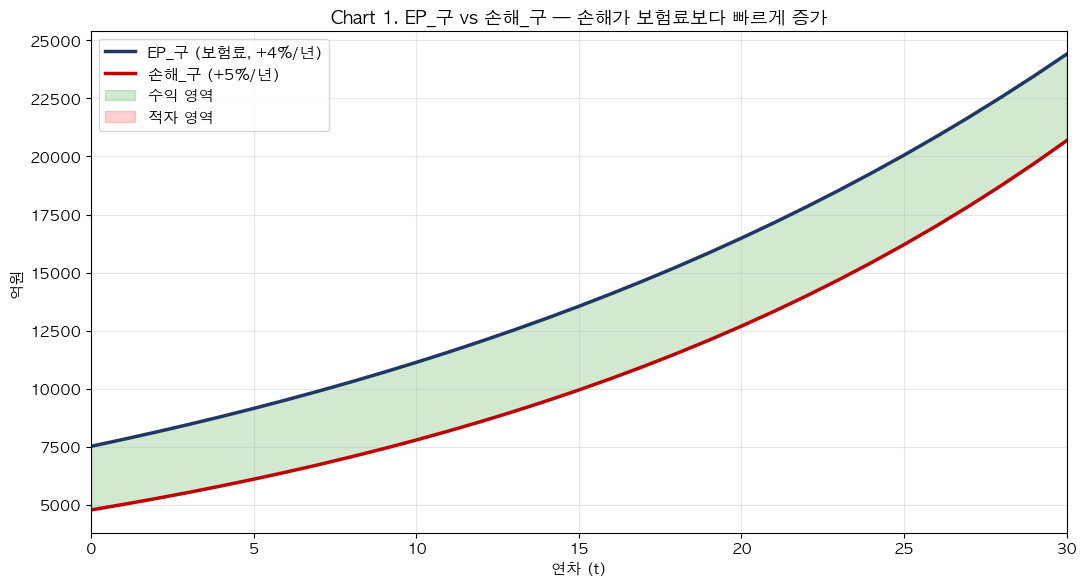

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(years, EP_old,   label=f'EP_구 (보험료, +{g_premium:.0%}/년)', color='#1F3864', linewidth=2.5)
ax.plot(years, Loss_old, label=f'손해_구 (+{g_actual:.0%}/년)',         color='#C00000', linewidth=2.5)
ax.fill_between(years, EP_old, Loss_old, where=(EP_old > Loss_old),  alpha=0.18, color='green', label='수익 영역')
ax.fill_between(years, EP_old, Loss_old, where=(EP_old <= Loss_old), alpha=0.18, color='red',   label='적자 영역')

ax.set_xlabel('연차 (t)')
ax.set_ylabel('억원')
ax.set_title('Chart 1. EP_구 vs 손해_구 — 손해가 보험료보다 빠르게 증가', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 30)

plt.tight_layout()
plt.show()

## 5. 시각화 — Chart 2 : 손해율 (LR) + 합계비율 (CR) trajectory

보험업 핵심 KPI 인 손해율과 합계비율의 시간 변화. 합계비율 (= 손해율 + 사업비율) 이 **100% 를 돌파하는 시점부터 단년 영업적자** 가 발생한다.

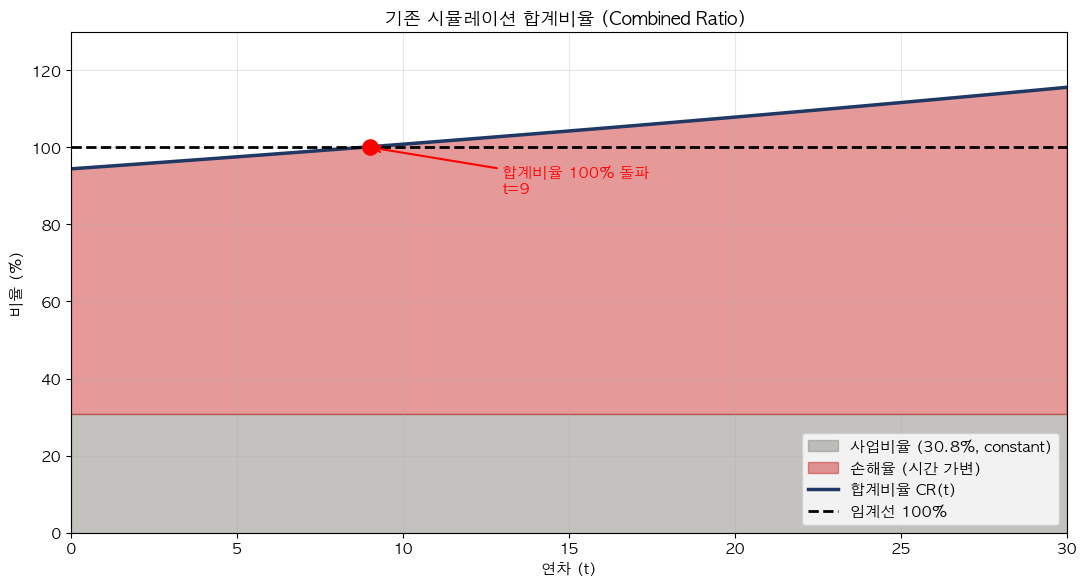

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))

# 사업비율 (constant) + 손해율 (시간 가변) 누적 표현
ax.fill_between(years, 0, ER_t * 100,         color='#888780', alpha=0.5, label=f'사업비율 ({ER_0:.1%}, constant)')
ax.fill_between(years, ER_t * 100, CR_t * 100, color='#C00000', alpha=0.4, label='손해율 (시간 가변)')
ax.plot(years, CR_t * 100, color='#1F3864', linewidth=2.5, label='합계비율 CR(t)')
ax.axhline(100, color='black', linestyle='--', linewidth=2, label='임계선 100%')

if cr_100_year is not None:
    ax.scatter([cr_100_year], [CR_t[cr_100_year]*100], color='red', s=120, zorder=5)
    ax.annotate(f'합계비율 100% 돌파\nt={cr_100_year}',
                xy=(cr_100_year, 100), xytext=(cr_100_year + 4, 88),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=11, color='red', fontweight='bold')

ax.set_xlabel('연차 (t)')
ax.set_ylabel('비율 (%)')
ax.set_title('기존 시뮬레이션 합계비율 (Combined Ratio) ', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim(0, 30)
ax.set_ylim(0, 130)

plt.tight_layout()
plt.show()

## 6. 시각화 — Chart 3 : 영업손익 단년 (annual)

매년의 영업손익을 막대그래프로 표현. 초반 t=0~8 년차에 흑자 유지, t=9 년차부터 적자 전환되며 이후 매년 적자 폭이 확대된다.

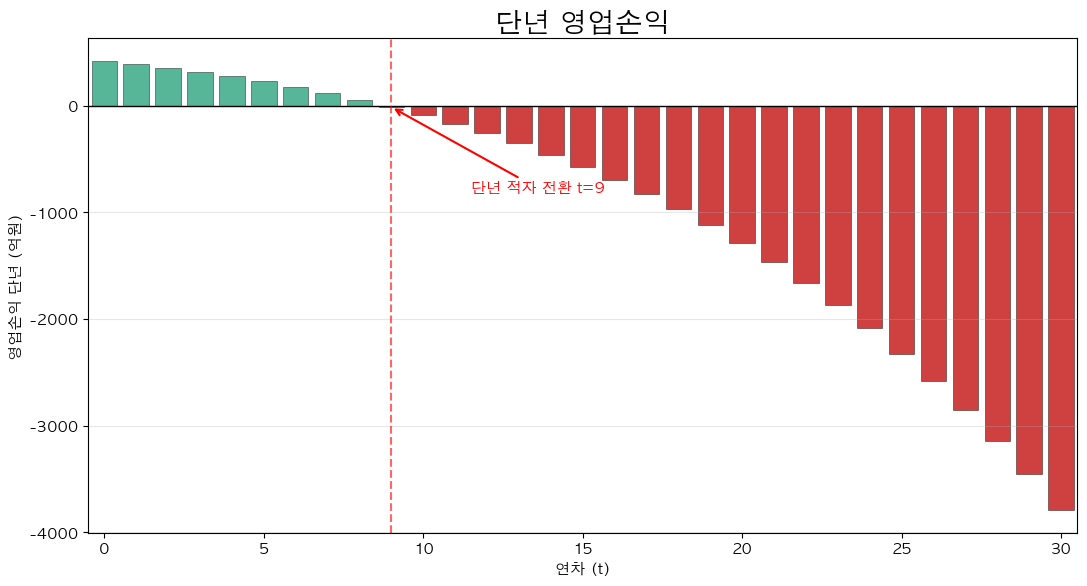

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))

colors_bar = ['#1D9E75' if p >= 0 else '#C00000' for p in Profit_old]
ax.bar(years, Profit_old, color=colors_bar, alpha=0.75, edgecolor='black', linewidth=0.4)
ax.axhline(0, color='black', linewidth=1)

if deficit_year is not None:
    ax.axvline(deficit_year, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.annotate(f'단년 적자 전환 t={deficit_year}',
                xy=(deficit_year, Profit_old[deficit_year]),
                xytext=(deficit_year + 2.5, Profit_old[deficit_year] - 800),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=11, color='red', fontweight='bold')

ax.set_xlabel('연차 (t)')
ax.set_ylabel('영업손익 단년 (억원)')
ax.set_title('단년 영업손익', fontsize=20, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.set_xlim(-0.5, 30.5)

plt.tight_layout()
plt.show()

## 7. 시각화 — Chart 4 : 누적 NPV vs 누적 nominal

30년 누적 영업손익을 **할인 없는 nominal 누적** 과 **V1 할인율 ($r_{V1}$ = 2.7%) 적용 NPV 누적** 으로 비교. NPV 는 후기 적자의 시간가치를 반영하여 nominal 보다 손실 폭이 작게 나타나지만, 여전히 음수로 큰 누적 손실을 보인다.

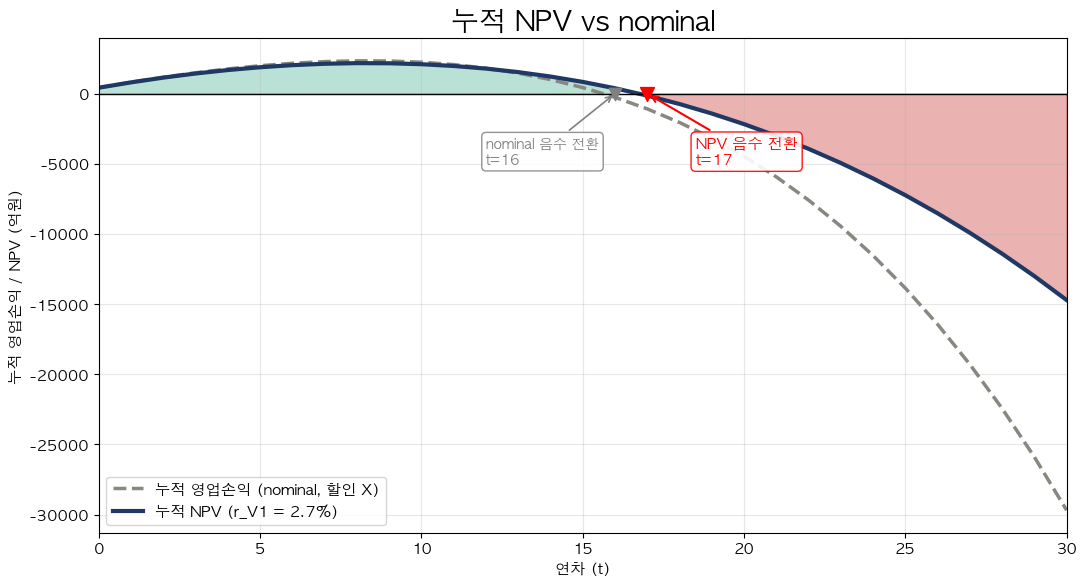

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))

# 두 종류 누적 곡선
ax.plot(years, Cum_Profit_nominal, color='#888780', linewidth=2.5, linestyle='--',
        label='누적 영업손익 (nominal, 할인 X)')
ax.plot(years, Cum_NPV, color='#1F3864', linewidth=3, 
        label=f'누적 NPV (r_V1 = {r_V1:.1%})')

# 영역 채우기 (NPV 기준)
ax.fill_between(years, 0, Cum_NPV, where=(Cum_NPV >= 0), alpha=0.3, color='#1D9E75')
ax.fill_between(years, 0, Cum_NPV, where=(Cum_NPV < 0),  alpha=0.3, color='#C00000')
ax.axhline(0, color='black', linewidth=1)

# BE 마커
if cum_neg_year is not None:
    ax.scatter([cum_neg_year], [0], color='gray', s=80, marker='v', zorder=5)
    ax.annotate(
        f'nominal 음수 전환\nt={cum_neg_year}',
        xy=(cum_neg_year, 0), xytext=(cum_neg_year - 4, -5000),
        textcoords='data',
        arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
        fontsize=10, color='gray',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.85)
    )

if npv_neg_year is not None:
    ax.scatter([npv_neg_year], [0], color='red', s=100, marker='v', zorder=5)
    ax.annotate(
        f'NPV 음수 전환\nt={npv_neg_year}',
        xy=(npv_neg_year, 0), xytext=(npv_neg_year + 1.5, -5000),
        textcoords='data',
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
        fontsize=11, color='red', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.9)
    )

ax.set_xlabel('연차 (t)')
ax.set_ylabel('누적 영업손익 / NPV (억원)')
ax.set_title(f'누적 NPV vs nominal',
             fontsize=20, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 30)

plt.tight_layout()
plt.show()


## 8. 손해 누적의 메커니즘 분석

### 8.1 복리 격차 효과

구모델 손실 누적의 근본 원인은 손해 가속률 ($g_{actual}$=5%) 이 보험료 인상률 ($g_{premium}$=4%) 보다 1%p 빠르다는 점이다. 이 격차가 30년 복리 작용한다.

In [19]:
# 복리 효과 정량화 표
print('=' * 78)
print('복리 격차 효과 — 30년간 누적')
print('=' * 78)
print(f"{'시점':>4} {'EP 배수':>10} {'손해 배수':>10} {'손해율 LR(t)':>14} {'합계비율 CR(t)':>14} {'영업이익률':>12}")
print('-' * 78)
for t in [0, 5, 10, 15, 20, 25, 30]:
    ep_mult   = (1 + g_premium) ** t
    loss_mult = (1 + g_actual)  ** t
    lr        = LR_0 * loss_mult / ep_mult
    cr        = lr + ER_0
    margin    = 1 - cr
    print(f'{t:>4} {ep_mult:>10.4f} {loss_mult:>10.4f} {lr:>14.2%} {cr:>14.2%} {margin:>12.2%}')

# 이론적 단년 적자 진입 시점 (analytical)
import math
ratio       = (1 - ER_0) / LR_0
t_breakeven = math.log(ratio) / math.log((1 + g_actual) / (1 + g_premium))
print()
print(f'이론적 단년 적자 전환 시점 (analytical) : t = {t_breakeven:.2f} 년')
print(f'시뮬레이션 결과                            : t = {deficit_year} 년 ✓')

복리 격차 효과 — 30년간 누적
  시점      EP 배수      손해 배수      손해율 LR(t)     합계비율 CR(t)        영업이익률
------------------------------------------------------------------------------
   0     1.0000     1.0000         63.60%         94.40%        5.60%
   5     1.2167     1.2763         66.71%         97.51%        2.49%
  10     1.4802     1.6289         69.98%        100.78%       -0.78%
  15     1.8009     2.0789         73.41%        104.21%       -4.21%
  20     2.1911     2.6533         77.01%        107.81%       -7.81%
  25     2.6658     3.3864         80.79%        111.59%      -11.59%
  30     3.2434     4.3219         84.74%        115.54%      -15.54%

이론적 단년 적자 전환 시점 (analytical) : t = 8.82 년
시뮬레이션 결과                            : t = 9 년 ✓


### 8.2 30년 시점 손익 분해

만약 손해도 보험료와 같은 4%/년 으로 증가했다면 어떤 차이가 났을까? (counterfactual)

In [20]:
# 30년 시점 분해 + counterfactual
t30 = 30
loss30_if_same   = Loss_0 * (1 + g_premium) ** 30
extra_loss       = Loss_old[t30] - loss30_if_same

print('=' * 65)
print('t = 30 시점 단년 분해')
print('=' * 65)
print(f'EP_구          = {EP_old[t30]:>12,.1f} 억')
print(f'손해_구        = {Loss_old[t30]:>12,.1f} 억   (LR = {Loss_old[t30]/EP_old[t30]:.2%})')
print(f'사업비_구      = {Expense_old[t30]:>12,.1f} 억   (ER = {Expense_old[t30]/EP_old[t30]:.2%})')
print(f'영업손익_구   = {Profit_old[t30]:>+12,.1f} 억   (마진 = {Profit_old[t30]/EP_old[t30]:.2%})')
print()
print('=' * 65)
print('30년 누적 결과')
print('=' * 65)
print(f'30년 누적 영업손익 (nominal)  : {Cum_Profit_nominal[30]:>+12,.1f} 억')
print(f'30년 누적 NPV  (r_V1 = {r_V1:.1%}) : {Cum_NPV[30]:>+12,.1f} 억')
print()
print('-' * 65)
print('Counterfactual : 손해도 4% 로만 증가했다면?')
print('-' * 65)
print(f'가상 손해(30)               = {loss30_if_same:>10,.1f} 억')
print(f'실제 손해 − 가상 손해      = {extra_loss:>+10,.1f} 억')
print(f'추가 손해 비율               = {extra_loss/loss30_if_same:>10.2%}')

t = 30 시점 단년 분해
EP_구          =     24,403.2 억
손해_구        =     20,680.5 억   (LR = 84.74%)
사업비_구      =      7,516.2 억   (ER = 30.80%)
영업손익_구   =     -3,793.5 억   (마진 = -15.54%)

30년 누적 결과
30년 누적 영업손익 (nominal)  :    -29,692.4 억
30년 누적 NPV  (r_V1 = 2.7%) :    -14,713.3 억

-----------------------------------------------------------------
Counterfactual : 손해도 4% 로만 증가했다면?
-----------------------------------------------------------------
가상 손해(30)               =   15,519.6 억
실제 손해 − 가상 손해      =   +5,160.8 억
추가 손해 비율               =     33.25%


## 9. 결론 — 구모델이 지속 손실 구조인 이유

### 핵심 메커니즘 (4단계)

1. **얇은 마진 출발선 (t=0)**
   - 영업이익률 +5.60%, 합계비율 94.40%
   - 작은 충격에도 무너지는 구조

2. **Δg=1%p 의 복리 누적 (t=0 → 30)**
   - 손해율 63.60% → 84.74% (+21.14%p)
   - 합계비율 94.40% → 115.54%

3. **단년 적자 진입 (t=9년)**
   - CR > 100% 돌파 직후
   - 이후 매년 적자 폭 확대

4. **누적 음수 전환**
   - nominal 누적: t=16년차
   - NPV (r_V1=2.7%) 누적: 약 t=17~18년차

### 학술적 의미

본 구모델 결과는 **보험사가 환경·물리적리스크를 가격 메커니즘에 반영하지 않을 경우 장기 자본 잠식이 구조적으로 발생함** 을 보여준다. 이것이 신모델 (ESG underwriting + PRF 반영 + V2 + AA) 도입의 정당성을 뒷받침하는 baseline 시나리오이다.

신모델 도입 시 η_LR=0.5 scenario 에서 30년 누적 NPV +4,268억원 (BE t=25년) 으로 약 **34,000억원 규모의 손익 swing** 이 가능하다.

In [13]:
# 최종 요약 테이블
summary = pd.DataFrame({
    'KPI'             : ['EP_구', '손해_구', '사업비_구',
                           '영업손익 단년', '누적 손익 (nominal)', '누적 NPV',
                           '손해율 LR(t)', '합계비율 CR(t)', '영업이익률'],
    't=0'             : [f'{EP_old[0]:,.0f}',  f'{Loss_old[0]:,.0f}',  f'{Expense_old[0]:,.0f}',
                           f'+{Profit_old[0]:,.0f}', f'+{Cum_Profit_nominal[0]:,.0f}', f'+{Cum_NPV[0]:,.0f}',
                           f'{LR_t[0]:.2%}',   f'{CR_t[0]:.2%}',   f'+{Profit_old[0]/EP_old[0]:.2%}'],
    't=10'            : [f'{EP_old[10]:,.0f}', f'{Loss_old[10]:,.0f}', f'{Expense_old[10]:,.0f}',
                           f'{Profit_old[10]:,.0f}',  f'{Cum_Profit_nominal[10]:,.0f}',  f'{Cum_NPV[10]:,.0f}',
                           f'{LR_t[10]:.2%}',   f'{CR_t[10]:.2%}',   f'{Profit_old[10]/EP_old[10]:.2%}'],
    't=20'            : [f'{EP_old[20]:,.0f}', f'{Loss_old[20]:,.0f}', f'{Expense_old[20]:,.0f}',
                           f'{Profit_old[20]:,.0f}',  f'{Cum_Profit_nominal[20]:,.0f}',  f'{Cum_NPV[20]:,.0f}',
                           f'{LR_t[20]:.2%}',   f'{CR_t[20]:.2%}',   f'{Profit_old[20]/EP_old[20]:.2%}'],
    't=30'            : [f'{EP_old[30]:,.0f}', f'{Loss_old[30]:,.0f}', f'{Expense_old[30]:,.0f}',
                           f'{Profit_old[30]:,.0f}',  f'{Cum_Profit_nominal[30]:,.0f}',  f'{Cum_NPV[30]:,.0f}',
                           f'{LR_t[30]:.2%}',   f'{CR_t[30]:.2%}',   f'{Profit_old[30]/EP_old[30]:.2%}'],
})
summary.style.set_caption('구모델 핵심 KPI — 시점별 (단위: 억원, %)')

,KPI,t=0,t=10,t=20,t=30
0,EP_구,"7,524","11,137","16,486","24,403"
1,손해_구,"4,785","7,794","12,696","20,680"
2,사업비_구,"2,317","3,430","5,078","7,516"
3,영업손익 단년,+422,-87,"-1,288","-3,793"
4,누적 손익 (nominal),+422,"2,238","-4,466","-29,692"
5,누적 NPV,+422,"2,095","-2,174","-14,713"
6,손해율 LR(t),63.60%,69.98%,77.01%,84.74%
7,합계비율 CR(t),94.40%,100.78%,107.81%,115.54%
8,영업이익률,+5.60%,-0.78%,-7.81%,-15.54%
